In [10]:
import pickle
from itertools import zip_longest
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle
from scipy.spatial.distance import cdist

from analysis_helpers import Episode, Participant
from analysis_helpers.constants import EVENTSEG_EDGECOLOR

In [2]:
atlep1 = Episode('atlep1')
participants = Participant.load_all()

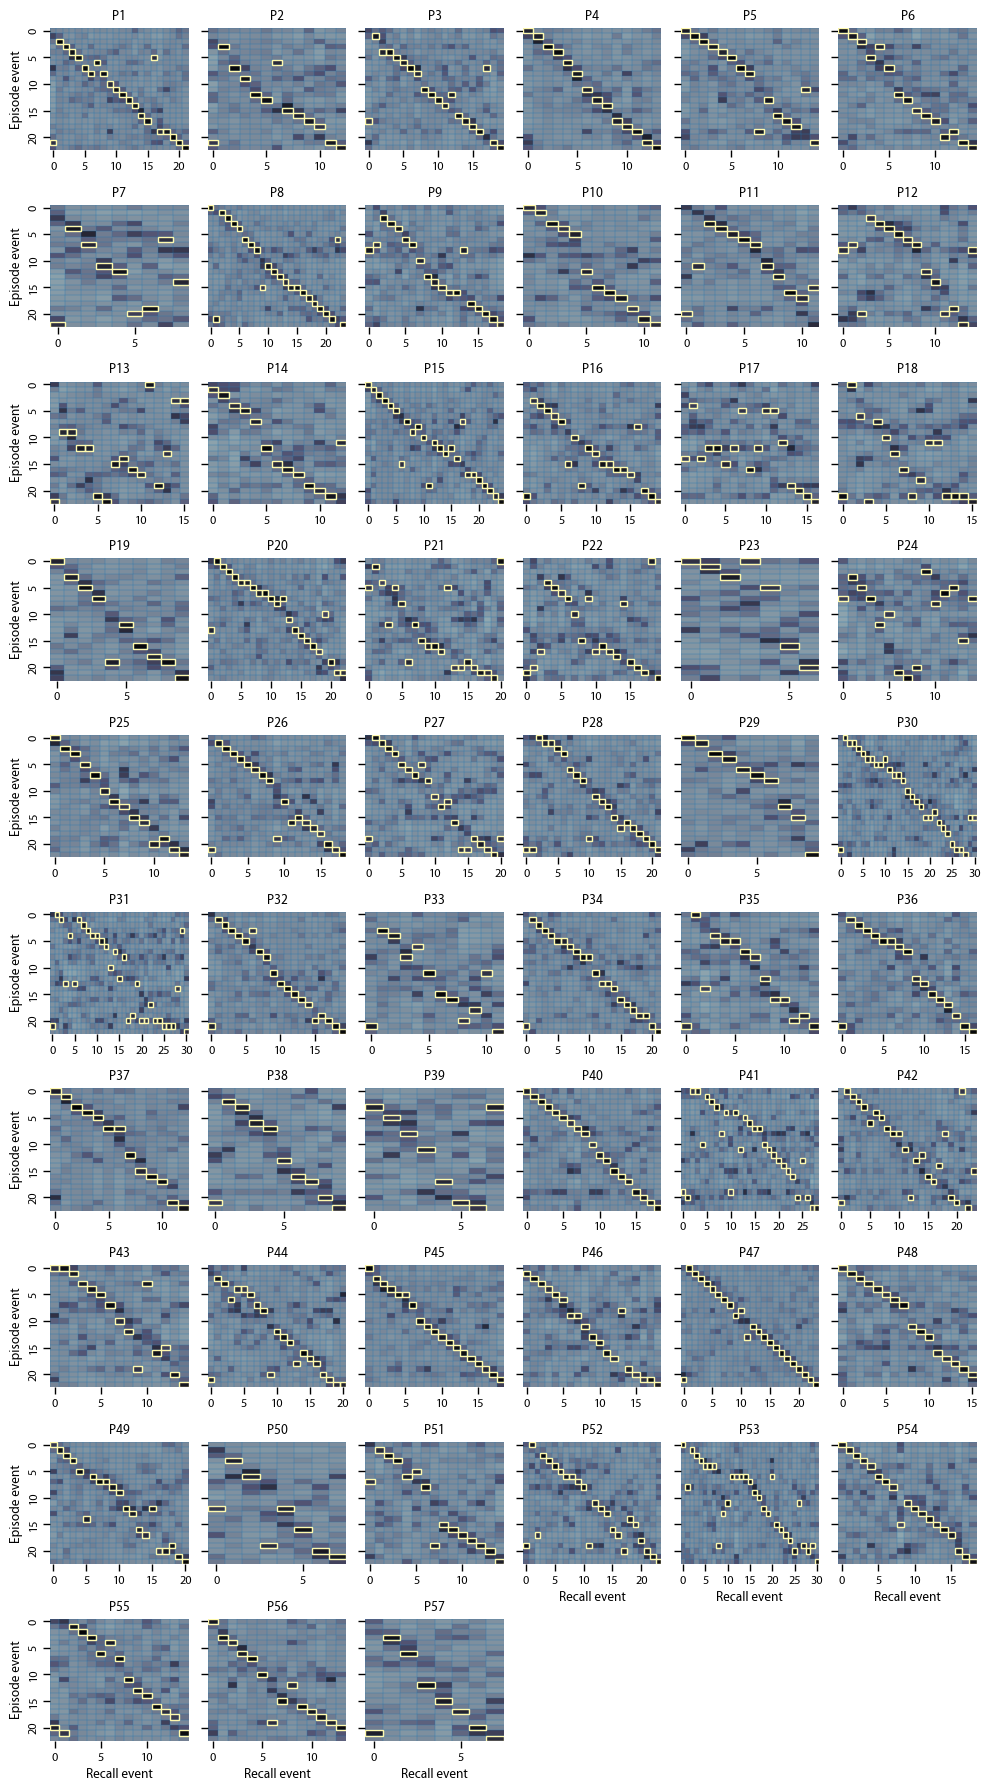

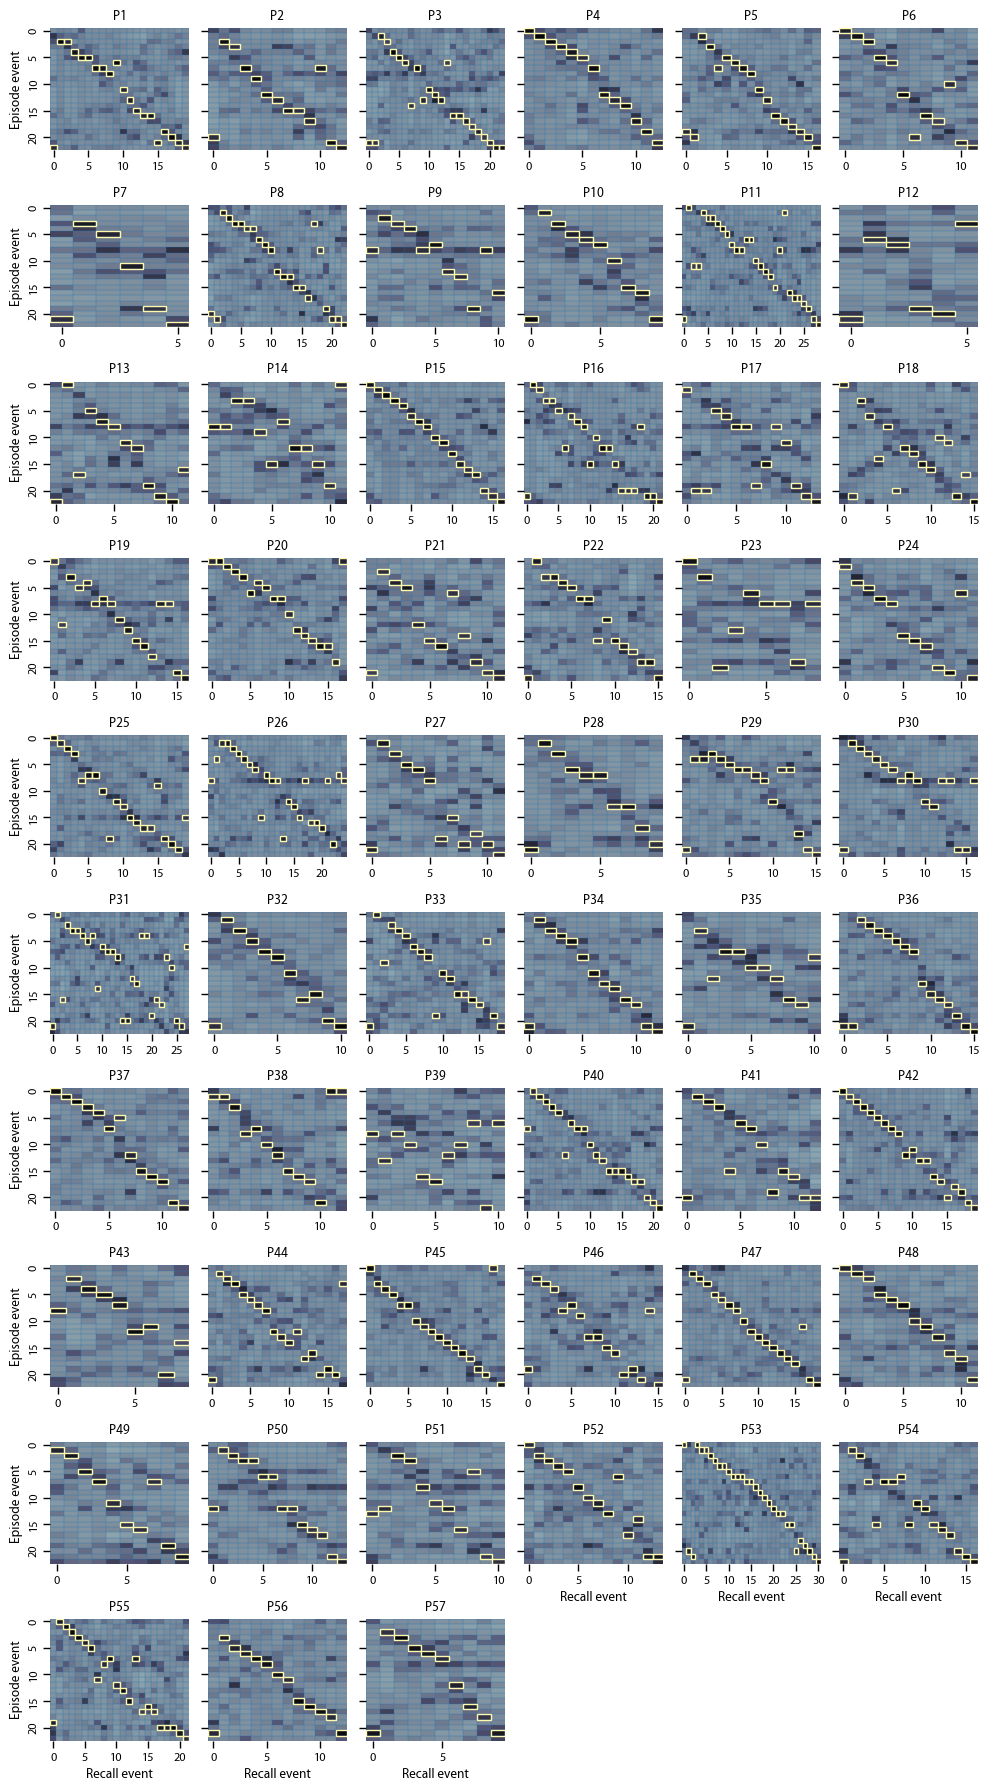

In [15]:
N_COLS = 6
with sns.plotting_context('paper'):
    for rectype in ('atlep1', 'delayed'):
        fig, axarr = plt.subplots(nrows=int(len(participants) / N_COLS) + 1, 
                                  ncols=N_COLS, 
                                  figsize=(10, 18))

        for i, (p, ax) in enumerate(zip_longest(participants, axarr.ravel())):
            if p is None:
                ax.axis('off')
                continue
                
            matchmat = 1 - cdist(atlep1.events, p.events[rectype], metric='correlation')
            sns.heatmap(matchmat, 
                        xticklabels=5, 
                        yticklabels=5, 
                        vmin=-1, 
                        vmax=1, 
                        cmap='bone_r', 
                        cbar=False, 
                        ax=ax)
            
            ax.hlines(range(matchmat.shape[0]), *ax.get_xlim(), linewidth=0.25)
            ax.vlines(range(matchmat.shape[1]), *ax.get_ylim(), linewidth=0.25)
            
            for bound_ix, bound in enumerate(matchmat.argmax(axis=0)):
                rect = Rectangle((bound_ix, bound), 
                                 width=1, 
                                 height=1, 
                                 linewidth=1, 
                                 edgecolor=EVENTSEG_EDGECOLOR, 
                                 facecolor='none', 
                                 zorder=2)
                ax.add_patch(rect)

            ax.set_title(f'P{p.sub_n}')

            if i >= len(participants) - N_COLS:
                ax.set_xlabel('Recall event')
#             else:
#                 ax.set_xticklabels([])

            if not i % N_COLS:
                ax.set_ylabel('Episode event')
            else:
                ax.set_yticklabels([])

        plt.tight_layout()#h_pad=0.1, w_pad=0.1)
        plt.show()
#         break

In [ ]:
def create_event_trajectory(
        trajectory: np.ndarray, 
        eventseg_model: EventSegment
) -> np.ndarray:
    """
    Reduce a timepoints x topics matrix to an events x topics matrix, 
    averaging topic weights over timepoints within each event.
    """
    labels = eventseg_model.segments_[0].argmax(axis=1)
    boundaries = np.flatnonzero(np.diff(labels)) + 1
    return np.vstack([
        chunk.mean(axis=0) for chunk in np.split(trajectory, boundaries)
    ])

